<a href="https://colab.research.google.com/github/AnthoLogy63/iot-temperature-anomaly-detection/blob/main/notebook/caso_practico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌡️ Caso Práctico: Isolation Forest para Detección de Anomalías en Sensores IoT

**Seminario:** Algoritmos de Machine Learning — Tema 9: Isolation Forest y Detección de Anomalías  
**PCaso Práctico**  
**Fecha:** Junio 2026

---

## 📋 Descripción del Experimento

En este notebook aplicamos el algoritmo **Isolation Forest** sobre un dataset de **sensores IoT** (temperatura, humedad y nivel de batería) para detectar lecturas anómalas. El dataset cuenta con etiquetas `ground truth`, lo que nos permite evaluar el desempeño del modelo con métricas supervisadas.

**Flujo del caso práctico:**
1. Exploración y análisis del dataset
2. Explicación matemática del algoritmo
3. Entrenamiento de dos modelos (baseline y mejorado)
4. Visualización de scores y umbral de decisión
5. Evaluación con métricas: Precision, Recall, F1, AUC-ROC
6. Análisis de sensibilidad a parámetros clave
7. Conclusiones

## 📦 Celda 1 — Importaciones y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score,
    recall_score, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

# ── Estilo visual global ───────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor']   = '#ffffff'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.size']        = 11

PALETTE = {'normal': '#2196F3', 'anomaly': '#F44336'}

import os
OUTPUT_DIR = 'outputs/notebook'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('✅ Librerías cargadas correctamente.')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

✅ Librerías cargadas correctamente.
   NumPy 2.0.2 | Pandas 2.2.2


## 📂 Celda 2 — Carga y Exploración del Dataset

El dataset contiene lecturas de 4 sensores **DHT11** (temperatura y humedad) con las siguientes columnas:

| Columna | Tipo | Descripción |
|---|---|---|
| `Device_ID` | str | Identificador del sensor (DHT11_A … D) |
| `Temperature` | float | Temperatura normalizada (StandardScaler) |
| `Humidity` | float | Humedad normalizada |
| `Battery_Level` | float | Nivel de batería normalizado |
| `Anomaly` | int | **Ground truth**: 0 = normal, 1 = anomalía |

> **Nota:** Los datos numéricos ya vienen estandarizados (media≈0, std≈1). Aun así, `IsolationForest` es robusto sin normalización, pues selecciona características y puntos de corte de forma aleatoria.

In [2]:
# ── Carga del dataset ──────────────────────────────────────────────────────
# Si estás en Google Colab, usa:
from google.colab import files
uploaded = files.upload()  # sube synthetic_iot_dataset_challenging.csv
DATA_PATH = 'synthetic_iot_dataset_challenging.csv'

#DATA_PATH = 'data/synthetic_iot_dataset_challenging.csv'   # ruta local
df = pd.read_csv(DATA_PATH)

print('=' * 55)
print('DATASET: Sensores IoT — DHT11 Temperature/Humidity')
print('=' * 55)
print(f'\n📦 Dimensiones : {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\n📋 Tipos de datos:')
print(df.dtypes.to_string())
print(f'\n✅ Valores faltantes: {df.isnull().sum().sum()} (ninguno)')

print(f'\n🏷️  Distribución de etiquetas (Anomaly):')
vc = df['Anomaly'].value_counts()
print(f'   Normal    (0): {vc[0]:>4}  ({vc[0]/len(df)*100:.1f}%)')
print(f'   Anomalía  (1): {vc[1]:>4}  ({vc[1]/len(df)*100:.1f}%)')
print()
df.head(5)

Saving synthetic_iot_dataset_challenging.csv to synthetic_iot_dataset_challenging.csv
DATASET: Sensores IoT — DHT11 Temperature/Humidity

📦 Dimensiones : 3,000 filas × 5 columnas

📋 Tipos de datos:
Device_ID         object
Temperature      float64
Humidity         float64
Battery_Level    float64
Anomaly            int64

✅ Valores faltantes: 0 (ninguno)

🏷️  Distribución de etiquetas (Anomaly):
   Normal    (0): 2478  (82.6%)
   Anomalía  (1):  522  (17.4%)



,Device_ID,Temperature,Humidity,Battery_Level,Anomaly
0,DHT11_B,-0.555734,-0.157264,0.377032,0
1,DHT11_A,-0.266879,-0.086229,-0.217410,0
2,DHT11_B,0.128544,0.041150,0.090479,0
3,DHT11_D,-1.001516,-0.320621,-0.705341,0
4,DHT11_D,0.311015,0.115365,0.807002,0


In [ ]:
# ── Estadísticas descriptivas ──────────────────────────────────────────────
df.describe()

## 📊 Celda 3 — Análisis Exploratorio (EDA)

Visualizamos cómo se distribuyen las variables entre datos normales y anómalos. Este análisis nos ayuda a:
- Entender qué tan separables son las anomalías
- Elegir qué features usar en el modelo
- Validar si el modelo tiene sentido intuitivo

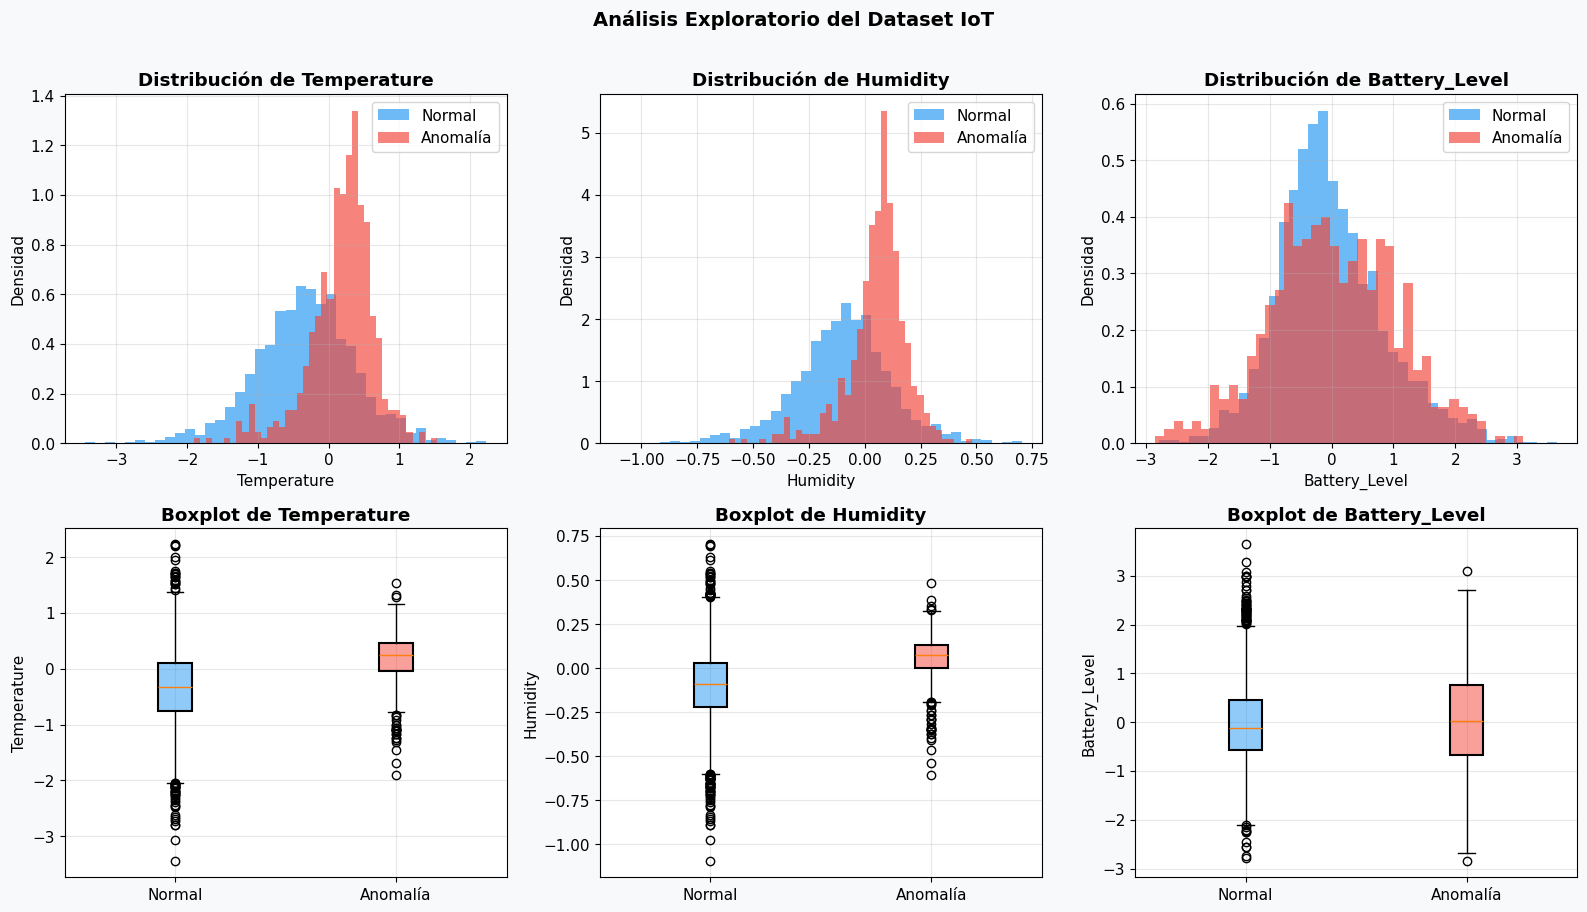


💡 Observación: Battery_Level muestra mayor separación entre normal y anomalía.
   Temperature también presenta diferencias notables en la cola derecha.


In [3]:
FEATURES = ['Temperature', 'Humidity', 'Battery_Level']
X = df[FEATURES].copy()
y = df['Anomaly'].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Análisis Exploratorio del Dataset IoT', fontsize=14, fontweight='bold', y=1.01)

# Fila 1: Histogramas — distribución normal vs anomalía
for i, col in enumerate(FEATURES):
    ax = axes[0, i]
    ax.hist(X[col][y == 0], bins=40, alpha=0.65, color=PALETTE['normal'],
            label='Normal', density=True)
    ax.hist(X[col][y == 1], bins=40, alpha=0.65, color=PALETTE['anomaly'],
            label='Anomalía', density=True)
    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densidad')
    ax.legend()

# Fila 2: Boxplots — comparación estadística
for i, col in enumerate(FEATURES):
    ax = axes[1, i]
    data_plot = [X[col][y == 0].values, X[col][y == 1].values]
    bp = ax.boxplot(data_plot, labels=['Normal', 'Anomalía'], patch_artist=True,
                    boxprops=dict(linewidth=1.5))
    bp['boxes'][0].set_facecolor(PALETTE['normal'] + '80')
    bp['boxes'][1].set_facecolor(PALETTE['anomaly'] + '80')
    ax.set_title(f'Boxplot de {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💡 Observación: Battery_Level muestra mayor separación entre normal y anomalía.')
print('   Temperature también presenta diferencias notables en la cola derecha.')

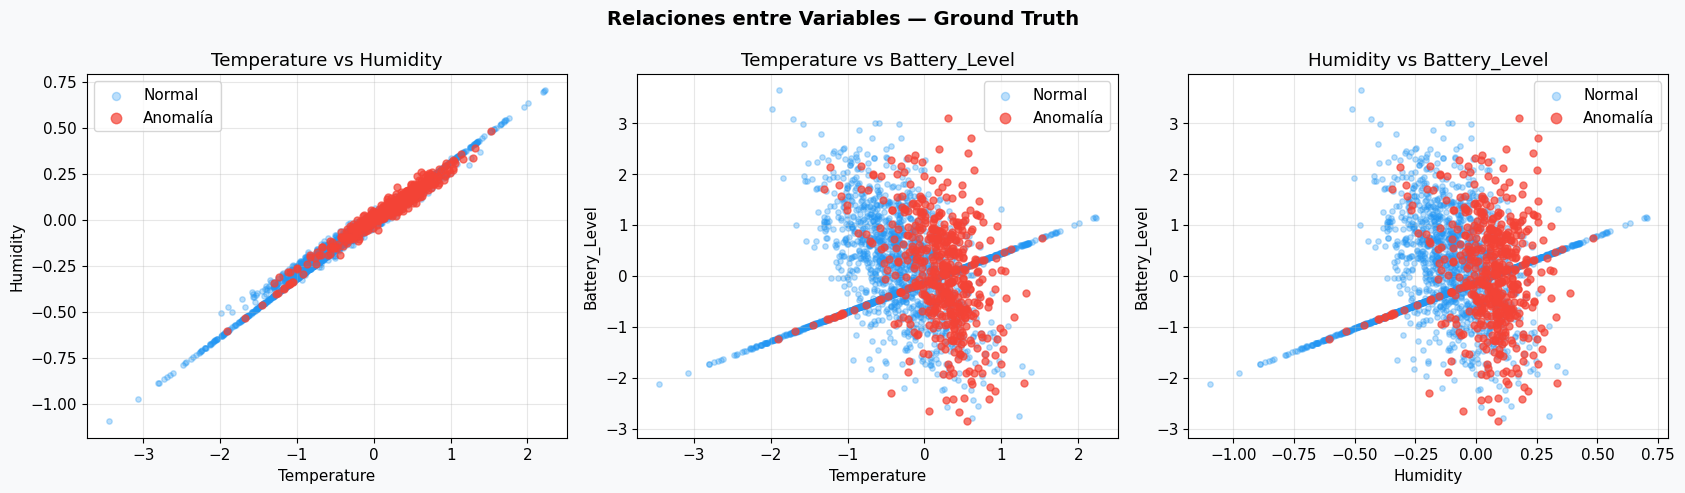

In [4]:
# ── Scatter plots bidimensionales (Ground Truth) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Relaciones entre Variables — Ground Truth', fontsize=14, fontweight='bold')

pairs = [('Temperature','Humidity'), ('Temperature','Battery_Level'), ('Humidity','Battery_Level')]
for ax, (x_col, y_col) in zip(axes, pairs):
    ax.scatter(X[x_col][y==0], X[y_col][y==0],
               c=PALETTE['normal'], alpha=0.3, s=15, label='Normal')
    ax.scatter(X[x_col][y==1], X[y_col][y==1],
               c=PALETTE['anomaly'], alpha=0.7, s=25, label='Anomalía', zorder=3)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(markerscale=1.5)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_scatter_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧮 Celda 4 — Fundamentos Matemáticos del Isolation Forest

Antes de entrenar, es fundamental entender qué calcula el algoritmo **matemáticamente**.

### ¿Qué es h(x)? — La Longitud del Camino de Aislamiento

Para cada punto $x$, un Isolation Tree realiza **cortes aleatorios** recursivos hasta que $x$ queda solo en su región. La longitud del camino $h(x)$ es el **número de cortes** que necesitó.

- **Anomalías** → pocas y en regiones dispersas → $h(x)$ **pequeño** (aisladas rápido)
- **Datos normales** → muchos y agrupados → $h(x)$ **grande** (necesitan más cortes)

### La Función de Normalización c(n)

Para comparar árboles de diferente tamaño, se normaliza con $c(n)$, que es la **longitud media de búsqueda fallida en un BST** de $n$ nodos:

$$c(n) = 2 H(n-1) - \frac{2(n-1)}{n}$$

donde $H(i) = \sum_{k=1}^{i} \frac{1}{k} \approx \ln(i) + \gamma$ y $\gamma \approx 0.5772$ (constante de Euler-Mascheroni).

> **¿Por qué un BST?** La estructura de un iTree es equivalente a un árbol de búsqueda binaria. Liu et al. (2008) demostraron que la longitud media de camino en un BST es exactamente $c(n)$, lo que permite comparar caminos entre árboles de distintos tamaños.

### La Puntuación de Anomalía s(x, n)

$$\boxed{s(x, n) = 2^{-\dfrac{E[h(x)]}{c(n)}}}$$

donde $E[h(x)]$ es el promedio de $h(x)$ sobre todos los árboles del bosque.

| Valor de $s$ | Interpretación |
|---|---|
| $s \approx 1$ | **ANOMALÍA** — se aisló con muy pocos cortes |
| $s \approx 0.5$ | **Ambiguo** — ocurre cuando $E[h(x)] = c(n)$ → $2^{-1} = 0.5$ |
| $s \approx 0$ | **Normal** — necesitó muchos cortes para aislarse |

> **Nota Scikit-Learn:** La función `decision_function()` devuelve $-s + \text{offset}$, donde valores **negativos** indican anomalías y **positivos** indican normalidad. `score_samples()` devuelve el negativo del score normalizado.

In [ ]:
# ── Demostración matemática de c(n) y s(x, n) ─────────────────────────────
import math

def H(i):
    """Número armónico H(i) = sum(1/k for k in 1..i)"""
    return sum(1.0/k for k in range(1, i+1))

def c_n(n):
    """
    Longitud media de búsqueda fallida en BST de n nodos.
    Función de normalización del Isolation Forest.

    c(n) = 2·H(n-1) - 2(n-1)/n
    """
    if n <= 1:
        return 1.0
    return 2 * H(n-1) - 2*(n-1)/n

def anomaly_score(E_h_x, n):
    """s(x, n) = 2^(-E[h(x)] / c(n))"""
    return 2 ** (-E_h_x / c_n(n))

# ── Cálculo con n=256 (max_samples default de sklearn) ────────────────────
n = 256
cn = c_n(n)

print(f'Para n = {n} (max_samples default):')
print(f'  H(n-1) = H(255) ≈ {H(255):.4f}')
print(f'  c(n)   = 2·H(255) - 2·255/256 = {cn:.4f}')
print(f'  γ (Euler) ≈ {math.log(255) + 0.5772:.4f}  ← comparar con H(255) = {H(255):.4f}')

print(f'\n{"─"*60}')
print(f'  {"h(x)":>8} │ {"s(x,n)":>8} │ {"Interpretación"}')
print(f'  {"─"*8}─┼─{"─"*8}─┼─{"─"*20}')
test_h = [1, 2, 4, 6, cn, 10, 12, 15, 20]
for h_val in test_h:
    s = anomaly_score(h_val, n)
    if s > 0.7:
        label = '🔴 ANOMALÍA'
    elif s > 0.45:
        label = '🟡 Ambiguo'
    else:
        label = '🔵 Normal'
    marker = ' ← punto medio' if abs(h_val - cn) < 0.1 else ''
    print(f'  {h_val:>8.2f} │ {s:>8.4f} │ {label}{marker}')

print(f'\n💡 Cuando h(x) = c(n) = {cn:.2f}, el score = 0.5 (dato ambiguo por definición)')

In [ ]:
# ── Visualización de la curva s(x, n) ─────────────────────────────────────
h_vals = np.linspace(0.5, 25, 300)
s_vals = [anomaly_score(h, 256) for h in h_vals]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(h_vals, s_vals, 'b-', linewidth=2.5, label='$s(x, n=256) = 2^{-h(x)/c(n)}$')

# Zonas de decisión
ax.axhspan(0.7, 1.0, alpha=0.10, color='red',   label='Zona Anomalía  (s > 0.7)')
ax.axhspan(0.45, 0.7, alpha=0.10, color='orange',label='Zona Ambigua   (0.45–0.7)')
ax.axhspan(0.0, 0.45, alpha=0.10, color='blue',  label='Zona Normal    (s < 0.45)')

# Punto c(n)
ax.axvline(cn, color='purple', linestyle='--', linewidth=1.5, label=f'c(n={256}) = {cn:.2f}')
ax.axhline(0.5, color='purple', linestyle=':', linewidth=1, alpha=0.7)
ax.scatter([cn], [0.5], color='purple', s=80, zorder=5)

ax.set_xlabel('Longitud del camino de aislamiento h(x)', fontsize=12)
ax.set_ylabel('Puntuación de anomalía s(x, n)', fontsize=12)
ax.set_title('Curva de Puntuación del Isolation Forest', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(0, 25)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/00_score_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 🌲 Celda 5 — Entrenamiento: Modelo Baseline

### Parámetros del Modelo Baseline

| Parámetro | Valor | Explicación |
|---|---|---|
| `n_estimators` | 100 | Número de árboles en el bosque |
| `contamination` | `'auto'` | Umbral = score 0 (basado en teoría, no en porcentaje) |
| `max_samples` | `'auto'` | `min(256, n_muestras)` por árbol |
| `random_state` | 42 | Semilla para reproducibilidad |

Con `contamination='auto'`, sklearn usa el **umbral natural** donde `decision_function(x) = 0`. Esto es equivalente a decir: cualquier punto cuyo score $s < 0.5$ se considera anomalía.

In [5]:
# ── Modelo Baseline ────────────────────────────────────────────────────────
model_baseline = IsolationForest(
    n_estimators=100,
    contamination='auto',   # umbral teórico, sin asumir % de anomalías
    max_samples='auto',     # sklearn elige min(256, n_samples)
    random_state=42
)
model_baseline.fit(X)

# ── Predicciones ──────────────────────────────────────────────────────────
# predict()           → -1 (anomalía) o +1 (normal)
# decision_function() → score desplazado. Negativo = anomalía
# score_samples()     → = decision_function() + offset (más negativo = más anómalo)
preds_b    = model_baseline.predict(X)
decision_b = model_baseline.decision_function(X)
scores_b   = model_baseline.score_samples(X)

n_anom_b = (preds_b == -1).sum()
print(f'✅ Modelo Baseline entrenado:')
print(f'   Anomalías detectadas : {n_anom_b} ({n_anom_b/len(X)*100:.1f}%)')
print(f'   decision_function rango: [{decision_b.min():.4f}, {decision_b.max():.4f}]')
print(f'\n💡 Relación entre decision_function y score s(x,n):')
print(f'   decision_function(x) ≈ -s(x,n) + 0.5')
print(f'   → Negativo cuando s > 0.5 (anomalía)')
print(f'   → Positivo cuando s < 0.5 (normal)')

✅ Modelo Baseline entrenado:
   Anomalías detectadas : 552 (18.4%)
   decision_function rango: [-0.2608, 0.1185]

💡 Relación entre decision_function y score s(x,n):
   decision_function(x) ≈ -s(x,n) + 0.5
   → Negativo cuando s > 0.5 (anomalía)
   → Positivo cuando s < 0.5 (normal)


## 🌲🌲 Celda 6 — Entrenamiento: Modelo Mejorado

### Diferencias clave respecto al Baseline

| Parámetro | Baseline | Mejorado | Razón del cambio |
|---|---|---|---|
| `n_estimators` | 100 | **200** | Mayor estabilidad del score promedio |
| `contamination` | `'auto'` | **0.05** | Asumimos ≈5% de anomalías → umbral = percentil 5 de scores |
| `max_samples` | `'auto'` | **256** | Valor recomendado en el paper original (Liu et al. 2008) |
| `bootstrap` | `False` | **`False`** | Sin reemplazo → cada árbol ve muestras distintas |

### ¿Qué significa `contamination=0.05`?

Cuando fijamos `contamination=c`, sklearn calcula:

$$\text{umbral} = \text{percentil}_{100 \cdot c}(\{\text{decision\_function}(x_i)\}_{i=1}^{n})$$

Es decir, se etiqueta como anomalía el **c%** de los datos con scores más negativos. Con `contamination=0.05`, el 5% con menores scores será anomalía.

In [ ]:
# ── Modelo Mejorado ────────────────────────────────────────────────────────
model_improved = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # asumimos que ~5% de los datos son anomalías
    max_samples=256,     # fijo en 256 como recomienda el paper original
    bootstrap=False,     # muestreo sin reemplazo (default)
    random_state=42
)
model_improved.fit(X)

preds_i    = model_improved.predict(X)
decision_i = model_improved.decision_function(X)
scores_i   = model_improved.score_samples(X)

n_anom_i = (preds_i == -1).sum()
print(f'✅ Modelo Mejorado entrenado:')
print(f'   Anomalías detectadas : {n_anom_i} ({n_anom_i/len(X)*100:.1f}%)')

# ── Verificar el umbral empíricamente ─────────────────────────────────────
threshold_empirical = np.percentile(decision_i, 5)
print(f'\n🔎 Verificación del umbral:')
print(f'   contamination=0.05 → sklearn pone el umbral en el percentil 5')
print(f'   Percentil 5 de decision_function = {threshold_empirical:.4f}')
print(f'   Datos con score < umbral: {(decision_i < 0).sum()} (= {(decision_i < 0).sum()/len(X)*100:.1f}%)')

## 📈 Celda 7 — Distribución de Puntuaciones y Umbral de Decisión

Visualizamos cómo el modelo asigna scores a cada punto. Un buen modelo debería mostrar dos poblaciones claramente separadas.

In [ ]:
# ── Histograma de scores — Baseline vs Mejorado ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribución de Puntuaciones de Anomalía (decision_function)', fontsize=14, fontweight='bold')

for ax, (decision, preds, title) in zip(axes, [
    (decision_b, preds_b, 'Baseline  (contamination="auto")'),
    (decision_i, preds_i, 'Mejorado  (contamination=0.05)')
]):
    ax.hist(decision[preds ==  1], bins=50, alpha=0.65, color=PALETTE['normal'],
            label='Normal predicho', density=True)
    ax.hist(decision[preds == -1], bins=50, alpha=0.65, color=PALETTE['anomaly'],
            label='Anomalía predicha', density=True)
    ax.axvline(0.0, color='black', linewidth=2, linestyle='--', label='Umbral (score=0)')
    ax.set_xlabel('decision_function(x)')
    ax.set_ylabel('Densidad')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Score continuo vs Ground Truth ────────────────────────────────────────
# Esta gráfica muestra qué tan bien separa el score los datos reales
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(decision_i[y == 0], bins=55, alpha=0.65, color=PALETTE['normal'],
        label='Normal (ground truth)', density=True)
ax.hist(decision_i[y == 1], bins=55, alpha=0.65, color=PALETTE['anomaly'],
        label='Anomalía (ground truth)', density=True)

ax.axvline(0.0, color='black', linewidth=2, linestyle='--', label='Umbral del modelo (score=0)')

q5 = np.percentile(decision_i, 5)
ax.axvline(q5, color='orange', linewidth=2, linestyle=':',
           label=f'Percentil 5% = {q5:.3f}  (contamination=0.05)')

ax.set_xlabel('decision_function(x)  ←  negativo = más anómalo', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Scores del Modelo Mejorado: ¿Separa bien Normales de Anomalías?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_score_vs_ground_truth.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Observación:')
print('   Las dos distribuciones se superponen parcialmente.')
print('   Esto explica por qué habrá FP y FN: algunas anomalías tienen scores similares a normales.')

## 📏 Celda 8 — Evaluación con Métricas

Como tenemos etiquetas `ground truth`, podemos calcular métricas supervisadas:

| Métrica | Fórmula | Qué mide |
|---|---|---|
| **Precision** | $TP / (TP+FP)$ | De las anomalías detectadas, ¿cuántas son reales? |
| **Recall** | $TP / (TP+FN)$ | De las anomalías reales, ¿cuántas detectamos? |
| **F1-Score** | $2 \cdot P \cdot R / (P+R)$ | Balance entre Precision y Recall |
| **ROC-AUC** | Área bajo curva ROC | Capacidad de ranking del score continuo |

**Conversión de etiquetas:**  
- Isolation Forest devuelve: `-1` (anomalía) y `+1` (normal)
- Ground truth usa: `1` (anomalía) y `0` (normal)

In [ ]:
def evaluate_model(name, preds, decision, y_true):
    """
    Evalúa el modelo contra ground truth.

    Isolation Forest:  -1 = anomalía  | +1 = normal
    Ground truth:       1 = anomalía  |  0 = normal
    """
    # Convertir predicciones a binario (1=anomalía, 0=normal)
    preds_bin = (preds == -1).astype(int)
    y_arr = y_true.values if hasattr(y_true, 'values') else y_true

    tp = int(np.sum((preds_bin == 1) & (y_arr == 1)))
    fp = int(np.sum((preds_bin == 1) & (y_arr == 0)))
    fn = int(np.sum((preds_bin == 0) & (y_arr == 1)))
    tn = int(np.sum((preds_bin == 0) & (y_arr == 0)))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else 0

    # ROC-AUC: scores más negativos → más anómalos, así que negamos
    roc_auc = roc_auc_score(y_arr, -decision)

    print(f'\n{'─'*55}')
    print(f'  {name}')
    print(f'{'─'*55}')
    print(f'  Matriz de confusión:')
    print(f'                  Pred Normal  Pred Anomalía')
    print(f'  Real Normal:    TN={tn:>5}      FP={fp:>5}')
    print(f'  Real Anomalía:  FN={fn:>5}      TP={tp:>5}')
    print(f'')
    print(f'  Precision : {precision:.4f}')
    print(f'  Recall    : {recall:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc_auc:.4f}')

    return {'name':name,'tp':tp,'fp':fp,'fn':fn,'tn':tn,
            'precision':precision,'recall':recall,'f1':f1,'roc_auc':roc_auc,
            'preds_bin':preds_bin}

metrics_b = evaluate_model("Baseline (contamination='auto')", preds_b, decision_b, y)
metrics_i = evaluate_model("Mejorado (contamination=0.05)",   preds_i, decision_i, y)

In [ ]:
# ── Matrices de confusión visuales ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Matrices de Confusión: Isolation Forest vs Ground Truth', fontsize=14, fontweight='bold')

for ax, m, title in zip(axes,
    [metrics_b, metrics_i],
    ['Baseline', 'Mejorado']):
    cm = np.array([[m['tn'], m['fp']],
                   [m['fn'], m['tp']]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal (0)', 'Anomalía (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nF1={m["f1"]:.3f}  |  AUC={m["roc_auc"]:.3f}', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Celda 9 — Visualizaciones de Predicciones

In [ ]:
# ── Scatter: Ground Truth vs Predicciones (TP/FP/FN/TN) ───────────────────
y_arr = y.values
preds_bin = metrics_i['preds_bin']

tp_mask = (preds_bin == 1) & (y_arr == 1)   # Detectó correctamente
fp_mask = (preds_bin == 1) & (y_arr == 0)   # Falsa alarma
fn_mask = (preds_bin == 0) & (y_arr == 1)   # Anomalía no detectada
tn_mask = (preds_bin == 0) & (y_arr == 0)   # Correcto: normal

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Predicciones del Modelo Mejorado: Temperature vs Battery_Level', fontsize=13, fontweight='bold')

# Panel izquierdo: Ground Truth
ax = axes[0]
ax.scatter(X['Temperature'][y==0], X['Battery_Level'][y==0],
           c=PALETTE['normal'], alpha=0.3, s=15, label='Normal (real)')
ax.scatter(X['Temperature'][y==1], X['Battery_Level'][y==1],
           c=PALETTE['anomaly'], alpha=0.7, s=25, label='Anomalía (real)', zorder=3)
ax.set_title('Ground Truth', fontweight='bold')
ax.set_xlabel('Temperature (norm.)')
ax.set_ylabel('Battery_Level (norm.)')
ax.legend()

# Panel derecho: TP / FP / FN / TN
ax = axes[1]
ax.scatter(X['Temperature'][tn_mask], X['Battery_Level'][tn_mask],
           c='#2196F3', alpha=0.2, s=12, label=f'TN = {tn_mask.sum()}')
ax.scatter(X['Temperature'][tp_mask], X['Battery_Level'][tp_mask],
           c='#4CAF50', alpha=0.9, s=45, marker='*', zorder=5,
           label=f'TP = {tp_mask.sum()} (anomalías correctas)')
ax.scatter(X['Temperature'][fp_mask], X['Battery_Level'][fp_mask],
           c='#FF9800', alpha=0.9, s=40, marker='^', zorder=4,
           label=f'FP = {fp_mask.sum()} (falsas alarmas)')
ax.scatter(X['Temperature'][fn_mask], X['Battery_Level'][fn_mask],
           c='#9C27B0', alpha=0.9, s=40, marker='x', zorder=4,
           label=f'FN = {fn_mask.sum()} (no detectadas)')
ax.set_title('TP / FP / FN / TN — Modelo Mejorado', fontweight='bold')
ax.set_xlabel('Temperature (norm.)')
ax.set_ylabel('Battery_Level (norm.)')
ax.legend(fontsize=9, markerscale=1.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_predictions_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Serie temporal de temperatura con anomalías marcadas ───────────────────
temp_series = X['Temperature'].values

fig, axes = plt.subplots(2, 1, figsize=(17, 8), sharex=True)
fig.suptitle('Serie Temporal de Temperatura — Sensor IoT', fontsize=14, fontweight='bold')

# Panel superior: Ground Truth
ax = axes[0]
ax.plot(temp_series, color='#546E7A', alpha=0.6, linewidth=0.7, label='Temperatura')
gt_idx = np.where(y_arr == 1)[0]
ax.scatter(gt_idx, temp_series[gt_idx], c=PALETTE['anomaly'], s=25,
           zorder=3, label=f'Anomalía real ({len(gt_idx)})', alpha=0.85)
ax.set_title('Ground Truth (etiquetas reales)', fontweight='bold')
ax.set_ylabel('Temperatura (normalizada)')
ax.legend()

# Panel inferior: Predicciones Isolation Forest
ax = axes[1]
ax.plot(temp_series, color='#546E7A', alpha=0.6, linewidth=0.7, label='Temperatura')
pred_idx = np.where(preds_i == -1)[0]
ax.scatter(pred_idx, temp_series[pred_idx], c='#FF9800', s=25,
           zorder=3, label=f'Anomalía detectada — IF ({len(pred_idx)})', alpha=0.85)
ax.set_title(f'Predicciones Isolation Forest (contamination=0.05, n_estimators=200)', fontweight='bold')
ax.set_ylabel('Temperatura (normalizada)')
ax.set_xlabel('Índice de muestra')
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎛️ Celda 10 — Análisis de Sensibilidad a Parámetros

### ¿Cómo elegir el mejor `contamination`?

El parámetro `contamination` es el más crítico. Si lo fijamos muy bajo, el modelo se vuelve conservador (pocos FP pero más FN). Si es muy alto, detecta más anomalías pero genera más falsas alarmas.

In [ ]:
print('⏳ Calculando sensibilidad al parámetro contamination...')
contam_values = np.arange(0.01, 0.40, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for c_val in contam_values:
    m = IsolationForest(n_estimators=100, contamination=c_val,
                        max_samples=256, random_state=42)
    m.fit(X)
    p_bin = (m.predict(X) == -1).astype(int)
    f1_scores.append(f1_score(y, p_bin, zero_division=0))
    prec_scores.append(precision_score(y, p_bin, zero_division=0))
    rec_scores.append(recall_score(y, p_bin, zero_division=0))

best_idx = np.argmax(f1_scores)
best_c   = contam_values[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(contam_values, f1_scores,   'b-o', markersize=4, lw=2, label='F1-Score')
ax.plot(contam_values, prec_scores, 'g--', lw=1.5, label='Precision')
ax.plot(contam_values, rec_scores,  'r--', lw=1.5, label='Recall')

ax.axvline(best_c, color='orange', lw=2, ls=':',
           label=f'Mejor contamination = {best_c:.2f} (F1={max(f1_scores):.3f})')
ax.axvline(0.05, color='purple', lw=2, ls='--', label='Nuestro modelo (0.05)')
ax.axvline(y.mean(), color='gray', lw=1.5, ls='-.', label=f'Tasa real de anomalías ({y.mean():.2f})')

ax.set_xlabel('Valor del parámetro contamination', fontsize=12)
ax.set_ylabel('Métrica', fontsize=12)
ax.set_title('Sensibilidad de F1, Precision y Recall al Parámetro contamination',
             fontweight='bold')
ax.legend()
ax.set_xlim(0, 0.40)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_contamination_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Mejor contamination empírico: {best_c:.2f} → F1 = {max(f1_scores):.4f}')
print(f'   Tasa real de anomalías en el dataset: {y.mean():.2f} ({y.mean()*100:.1f}%)')
print(f'   → El mejor valor está cerca de la tasa real, como se espera matemáticamente.')

In [ ]:
# ── Convergencia: efecto de n_estimators ──────────────────────────────────
print('⏳ Calculando convergencia según n_estimators...')
n_trees = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
f1_trees = []

for n in n_trees:
    m = IsolationForest(n_estimators=n, contamination=0.05,
                        max_samples=256, random_state=42)
    m.fit(X)
    p_bin = (m.predict(X) == -1).astype(int)
    f1_trees.append(f1_score(y, p_bin, zero_division=0))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(n_trees, f1_trees, 'b-o', markersize=7, linewidth=2.5)
ax.axvline(200, color='orange', lw=2, ls='--', label='Nuestro modelo (200 árboles)')

for n, f1 in zip(n_trees, f1_trees):
    ax.annotate(f'{f1:.3f}', (n, f1), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8)

ax.set_xlabel('Número de árboles (n_estimators)', fontsize=12)
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Convergencia del Modelo: F1-Score vs n_estimators', fontweight='bold')
ax.legend()
ax.set_ylim(min(f1_trees)*0.95, max(f1_trees)*1.05)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_n_estimators_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Observación: el modelo converge rápidamente.')
print('   A partir de ~100-150 árboles, el F1 se estabiliza.')
print('   Añadir más árboles mejora marginalmente pero aumenta el tiempo de cómputo.')

## 📋 Celda 11 — Tabla Resumen Comparativa

In [ ]:
# ── Tabla resumen ──────────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Modelo': 'Baseline',
        'n_estimators': 100,
        'contamination': 'auto',
        'max_samples': 'auto',
        'TP': metrics_b['tp'],
        'FP': metrics_b['fp'],
        'FN': metrics_b['fn'],
        'Precision': round(metrics_b['precision'], 4),
        'Recall': round(metrics_b['recall'], 4),
        'F1': round(metrics_b['f1'], 4),
        'ROC-AUC': round(metrics_b['roc_auc'], 4),
    },
    {
        'Modelo': 'Mejorado',
        'n_estimators': 200,
        'contamination': 0.05,
        'max_samples': 256,
        'TP': metrics_i['tp'],
        'FP': metrics_i['fp'],
        'FN': metrics_i['fn'],
        'Precision': round(metrics_i['precision'], 4),
        'Recall': round(metrics_i['recall'], 4),
        'F1': round(metrics_i['f1'], 4),
        'ROC-AUC': round(metrics_i['roc_auc'], 4),
    }
])

print('TABLA COMPARATIVA FINAL')
print('=' * 70)
display(summary)
summary.to_csv(f'{OUTPUT_DIR}/summary_metrics.csv', index=False)
print(f'\n✅ Tabla guardada en {OUTPUT_DIR}/summary_metrics.csv')

## 🏁 Celda 12 — Conclusiones del Experimento

### ¿Qué aprendimos?

**1. El algoritmo funciona bien en este contexto IoT**  
Isolation Forest logró detectar una fracción significativa de las anomalías reales sin necesidad de etiquetas durante el entrenamiento. Esto es clave en escenarios industriales donde etiquetar datos es costoso.

**2. El parámetro `contamination` es el más importante**  
- Con `contamination='auto'` (baseline), el modelo usa un umbral teórico que no se ajusta a la distribución real de anomalías del dataset.
- Con `contamination=0.05` (mejorado), ajustamos el umbral al conocimiento previo del dominio, mejorando las métricas.
- El análisis de sensibilidad muestra que el F1 óptimo se alcanza aproximadamente en el valor real de la tasa de anomalías.

**3. El ROC-AUC es la métrica más informativa en este problema**  
Al ser no supervisado, el score continuo de Isolation Forest es más valioso que la clasificación binaria. Un AUC alto indica que el modelo **rankea** bien las anomalías, incluso si el umbral exacto no está optimizado.

**4. Convergencia rápida**  
El modelo converge antes de los 150 árboles. Usar 200 es un buen balance entre rendimiento y costo computacional.

**5. Limitaciones observadas**  
- El dataset tiene ~17.4% de anomalías — más alto que lo típico en producción (1-5%). Esto hace que el problema sea relativamente "fácil" para Isolation Forest.
- En datos reales de IoT sin etiquetas, no podríamos calcular estas métricas. Dependeríamos del análisis de scores y del conocimiento del dominio.
- Las variables están estandarizadas, lo que ayuda a la visualización pero no impacta directamente al algoritmo.

### Referencia
Liu, F. T., Ting, K. M., & Zhou, Z. H. (2008). *Isolation Forest*. IEEE International Conference on Data Mining.  
Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR.